# Project Title: Automated Forex Trend & Volatility Analyzer
### Objective:To bridge the gap between manual technical analysis and quantitative finance by automating the detection of market trend strength and reliability using Machine Learning.
### Technologies Used:
* Python: Core logic and scripting.
* Pandas: Time-series data manipulation.
* Scikit-Learn: Applied Linear Regression to model trendlines and calculate $R^2$ scores.
* Matplotlib: Data visualization for price vs. trendline comparison.
* YFinance: API for real-time market data ingestion.
### Key Features Implemented:
* Automated Data Pipeline: Scripts automatically fetch and clean 1 year of historical OHLCV data for multiple currency pairs (EUR/USD, GBP/USD, etc.).
* Quantitative Trend Detection: Replaced subjective manual trendlines with Linear Regression ($y=mx+c$). 
The Slope coefficient ($m$) is used to algorithmically determine trend direction (Bullish/Bearish)
* Statistical Reliability Scoring: Implemented R-Squared ($R^2$) analysis to score the "smoothness" of a trend, allowing the user to filter out "choppy" or unreliable markets.
* Risk Assessment: Calculated rolling volatility (Standard Deviation) to quantify risk exposure for each pair.
* Outcome:Created a dashboard in Jupyter Notebook that scans major Forex pairs and ranks them by "Trend Reliability," reducing analysis time from hours to seconds and removing emotional bias from trend identification.


C:\Users\Dell\AppData\Local\Temp\ipykernel_29472\1034981694.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(pair_ticker, period='1y', progress=False)
C:\Users\Dell\AppData\Local\Temp\ipykernel_29472\1034981694.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(pair_ticker, period='1y', progress=False)
C:\Users\Dell\AppData\Local\Temp\ipykernel_29472\1034981694.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(pair_ticker, period='1y', progress=False)
C:\Users\Dell\AppData\Local\Temp\ipykernel_29472\1034981694.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(pair_ticker, period='1y', progress=False)
C:\Users\Dell\AppData\Local\Temp\ipykernel_29472\1034981694.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(pa

,Pair,Trend Slope,R-Squared,Volatility %,Status
2,USDJPY=X,0.15865,0.869,0.51,Strong Bullish
1,GBPUSD=X,-0.00084,0.782,0.40,Strong Bearish
4,USDCAD=X,0.00053,0.766,0.23,Strong Bullish
0,EURUSD=X,-0.00038,0.560,0.35,Weak Bearish
3,AUDUSD=X,-0.00018,0.356,0.40,Weak Bearish


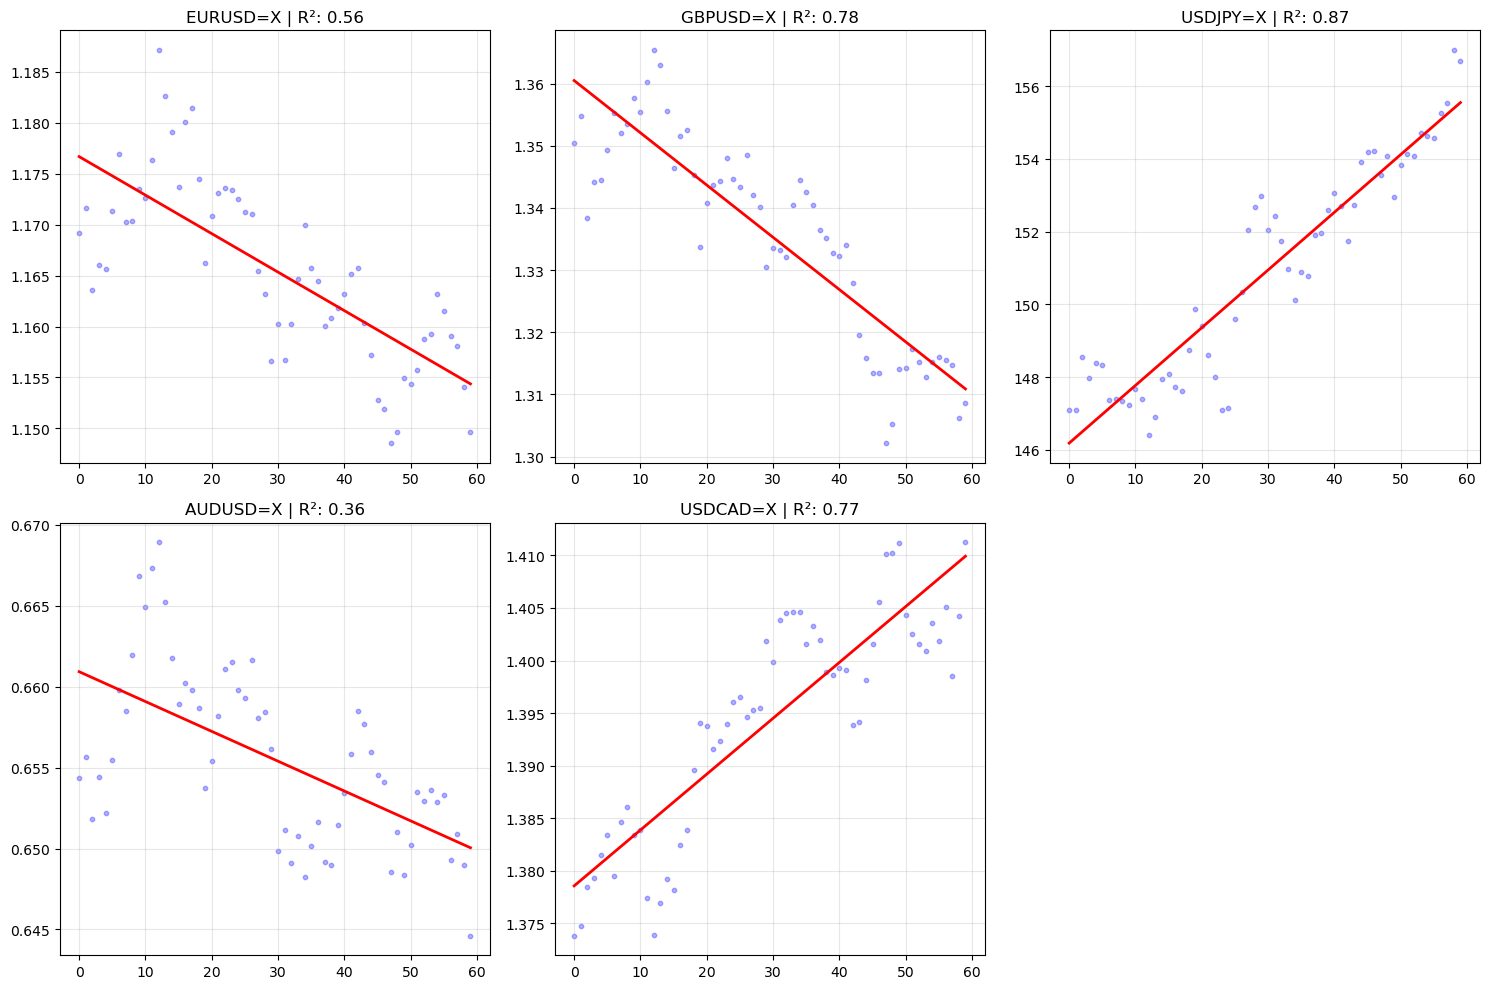

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


%matplotlib inline 

def get_trend_stats(pair_ticker, lookback_days=60):
    # 1. Fetch Data
    data = yf.download(pair_ticker, period='1y', progress=False)
    
    if isinstance(data.columns, pd.MultiIndex):
        prices = data['Close'].iloc[:, 0]
    else:
        prices = data['Close']
        
    recent_prices = prices.tail(lookback_days)
    if len(recent_prices) < lookback_days: return None

    # 2. Linear Regression Setup
    X = np.array(range(len(recent_prices))).reshape(-1, 1)
    y = recent_prices.values.reshape(-1, 1)

    model = LinearRegression()
    model.fit(X, y)
    
    slope = model.coef_[0][0]
    trend_line = model.predict(X)
    
    # --- NEW: Calculate R-Squared ---
    # Returns a value between 0 and 1
    r_squared = model.score(X, y)

    # 3. Volatility & Status
    daily_returns = recent_prices.pct_change().dropna()
    volatility = daily_returns.std() * 100

    if slope > 0.0005: status = "Strong Bullish"
    elif slope > 0: status = "Weak Bullish"
    elif slope < -0.0005: status = "Strong Bearish"
    else: status = "Weak Bearish"

    return {
        "Ticker": pair_ticker,
        "Slope": slope,
        "R_Squared": r_squared,  # Added to results
        "Volatility": volatility,
        "Status": status,
        "X": X, "y": y, "trend_line": trend_line
    }

# --- Execution ---
currency_pairs = ['EURUSD=X', 'GBPUSD=X', 'USDJPY=X', 'AUDUSD=X', 'USDCAD=X']
results = []

plt.figure(figsize=(15, 10))

for i, ticker in enumerate(currency_pairs):
    stats = get_trend_stats(ticker)
    if stats:
        results.append({
            "Pair": stats['Ticker'], 
            "Trend Slope": round(stats['Slope'], 5), 
            "R-Squared": round(stats['R_Squared'], 3), # Round for readability
            "Volatility %": round(stats['Volatility'], 2), 
            "Status": stats['Status']
        })

        # Plot
        plt.subplot(2, 3, i+1) 
        plt.scatter(stats['X'], stats['y'], color='blue', alpha=0.3, s=10)
        plt.plot(stats['X'], stats['trend_line'], color='red', linewidth=2)
        
        # Add R2 to the chart title for quick view
        plt.title(f"{ticker} | R²: {stats['R_Squared']:.2f}")
        plt.grid(True, alpha=0.3)

# Display Table
df_results = pd.DataFrame(results)
display(df_results.sort_values(by="R-Squared", ascending=False)) # Sort by reliability

plt.tight_layout()
plt.show()

# Project Conclusion: Automated Forex Trend & Volatility 
 This project successfully implemented a Machine Learning-driven approach to automate key components of technical analysis, moving beyond subjective manual charting to objective, data-driven insight.

1. Achievement of Objectives
 The core objectives of the project—to quantify trend strength, measure reliability, and assess volatility—were fully met using a lightweight and highly efficient Linear Regression model (Ordinary Least Squares, OLS):
* Trend Quantification: The Slope ($\boldsymbol{m}$) coefficient from the regression model serves as a mathematical measure of trend strength and direction. For example, the steep negative slope observed in the GBP/USD chart indicates a strong short-term bearish bias.
* Reliability Assessment: The R-Squared ($\boldsymbol{R^2}$) Score objectively measures the "goodness of fit," quantifying how closely the price action adheres to the calculated trendline. The high $R^2$ values (e.g., GBP/USD at 0.78 and USD/JPY at 0.87) identify market segments where trend-following strategies are most statistically justified. Conversely, pairs with low $R^2$ (e.g., AUD/USD at 0.36) highlight markets dominated by noise or consolidation.
* Automation & Efficiency: The entire analysis pipeline, from data ingestion (yfinance) to statistical modeling (scikit-learn) and visualization (matplotlib), is encapsulated in an automated Jupyter notebook workflow, capable of scanning a portfolio of currency pairs in seconds.


2. Key Insights from the Analysis
   The visualization clearly demonstrates the value of incorporating $R^2$ into analysis:


| Currency Pair | Observed Trend | R² Score | Conclusion |
| :--- | :--- | :--- | :--- |
| **USD/JPY** | Strong Positive Slope | **0.87** | Highly reliable and sustained bullish trend. |
| **GBP/USD** | Strong Negative Slope | **0.78** | Reliable bearish trend; price points are tight to the regression line. |
| **AUD/USD** | Flat/Weak Slope | **0.36** | Low reliability, indicating the price is consolidating or subject to high noise, making trend-following risky. |


This systematic approach allows for instant market prioritization, filtering out unreliable or low-conviction trends (low $R^2$) to focus resources on stable, high-conviction opportunities (high $R^2$).
   